# langraph

In [ ]:
# installations!
!pip install langchain-ollama
!pip install langchain-tavily
!pip install -U langgraph
!pip install langchain-google-genai langchain-core

In [ ]:
#model loading

import os
from langchain_ollama import ChatOllama

nemotron_chat_model = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}
    },
)
response = nemotron_chat_model.invoke("What is the color of the sky answer in one word?")
print(response.content)


Blue


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the model (you can use models like gemini-2.5-flash or gemini-pro)
gemini_chat_model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
response = gemini_chat_model.invoke("What is the color of the sky answer in one word?")
print(response.content)



Blue


# type of message

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


In [6]:
messages

[AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="Yes, that's right.", additional_kwargs={}, response_metadata={}, name='Lance'),
 AIMessage(content='Great, what would you like to learn about.', additional_kwargs={}, response_metadata={}, name='Model', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn about the best place to see Orcas in the US.', additional_kwargs={}, response_metadata={}, name='Lance')]

# what is langraph

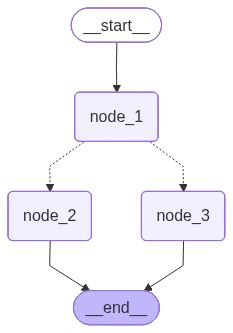

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}

In [ ]:
# simple dummy graph
##########################
# state
##############################
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

# node deffinitons
#############################

def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}


# coditional edge
############################
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state']
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        # 50% of the time, we return Node 2
        return "node_2"
    # 50% of the time, we return Node 3
    return "node_3"



# graph construction
###########################################
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))



# graph invoc
graph.invoke({"graph_state" : "Hi, this is Lance."})

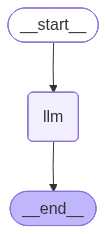

--- Calling LLM ---
{'question': 'What is LangGraph? answer in three words', 'answer': 'Graph-based language processing'}


In [15]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

# state
##################
class State(TypedDict):
    question: str
    answer: str

# model
#####################
llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}
    },
)

# node
#####################
def call_llm(state: State):

    print("--- Calling LLM ---")

    response = llm.invoke(state["question"])

    return {
        "answer": response.content
    }


# graph
#############
builder = StateGraph(State)

builder.add_node("llm", call_llm)

builder.add_edge(START, "llm")
builder.add_edge("llm", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


# invoke

result = graph.invoke(
    {
        "question": "What is LangGraph? answer in three words"
    }
)

print(result)

In [10]:
result

{'question': 'What is LangGraph? answer in three words',
 'answer': 'LangChain workflow graph'}

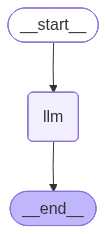

--- Calling LLM ---
{'messages': [HumanMessage(content='What is LangGraph? answer in three words', additional_kwargs={}, response_metadata={}, id='2629d08d-3229-4cb2-b676-cbbbc9049786')]}


In [16]:
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

# state
# ##################
# from typing import Annotated
# from typing_extensions import TypedDict

# from langgraph.graph.message import add_messages

# class MessagesState(TypedDict):
#     messages: Annotated[list, add_messages]

# model
#####################
llm = ChatOllama(
    model="nemotron-3-super:cloud",
    base_url="https://ollama.com",
    client_kwargs={
        "headers": {"Authorization": f"Bearer {OLLAMA_API_KEY}"}
    },
)

# node
#####################
def call_llm(state: MessagesState):

    print("--- Calling LLM ---")

    response = llm.invoke(state["messages"])

    return {
        "answer": response.content
    }


# graph
#############
builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)

builder.add_edge(START, "llm")
builder.add_edge("llm", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


# invoke

from langchain_core.messages import HumanMessage

result = graph.invoke(
    {
        "messages": [
            HumanMessage(content="What is LangGraph? answer in three words")
        ]
    }
)
print(result)

In [17]:
result

{'messages': [HumanMessage(content='What is LangGraph? answer in three words', additional_kwargs={}, response_metadata={}, id='2629d08d-3229-4cb2-b676-cbbbc9049786')]}

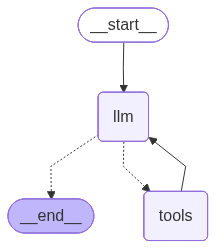

--- Calling LLM ---
--- Calling LLM ---
{'messages': [HumanMessage(content='What is 25 multiplied by 8?', additional_kwargs={}, response_metadata={}, id='089b4e1e-6e80-4511-88fe-e11bae1b2e13'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T06:42:06.727256536Z', 'done': True, 'done_reason': 'stop', 'total_duration': 586184642, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 73, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e81eb-0e03-72f2-ae17-16eb0dffc1c2-0', tool_calls=[{'name': 'multiply', 'args': {'a': 25, 'b': 8}, 'id': 'df4631cf-9023-4d12-9809-2e8568fdd909', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 73, 'total_tokens': 373}), ToolMessage(content='200', name='multiply', id='084d19dc-a612-4cd9-9a15-f99e9feb4da1', tool_call_id='

In [18]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])


def call_llm(state: MessagesState):

    print("--- Calling LLM ---")

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }


from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)

builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    tools_condition
)

builder.add_edge("tools", "llm")

graph = builder.compile()

from langchain_core.messages import HumanMessage

# View
display(Image(graph.get_graph().draw_mermaid_png()))


result = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="What is 25 multiplied by 8?"
            )
        ]
    }
)

print(result)

In [19]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 25 multiplied by 8?
================================== Ai Message ==================================
Tool Calls:
  multiply (df4631cf-9023-4d12-9809-2e8568fdd909)
 Call ID: df4631cf-9023-4d12-9809-2e8568fdd909
  Args:
    a: 25
    b: 8
================================= Tool Message =================================
Name: multiply

200
================================== Ai Message ==================================

25 multiplied by 8 is 200.


In [20]:
result

{'messages': [HumanMessage(content='What is 25 multiplied by 8?', additional_kwargs={}, response_metadata={}, id='089b4e1e-6e80-4511-88fe-e11bae1b2e13'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T06:42:06.727256536Z', 'done': True, 'done_reason': 'stop', 'total_duration': 586184642, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 73, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e81eb-0e03-72f2-ae17-16eb0dffc1c2-0', tool_calls=[{'name': 'multiply', 'args': {'a': 25, 'b': 8}, 'id': 'df4631cf-9023-4d12-9809-2e8568fdd909', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 73, 'total_tokens': 373}),
  ToolMessage(content='200', name='multiply', id='084d19dc-a612-4cd9-9a15-f99e9feb4da1', tool_call_id='df4631cf-9023-4d12-9809-2e8568fdd909

In [ ]:
# ToolNode

from langchain_core.messages import ToolMessage


def multiply(a: int, b: int) -> int:
    """Multiply a and b"""
    return a * b

tool_registry = {
    "multiply": multiply
}

def my_tool_node(state):

    last_message = state["messages"][-1]

    tool_messages = []

    for tool_call in last_message.tool_calls:

        tool_name = tool_call["name"]

        tool_args = tool_call["args"]

        tool_fn = tool_registry[tool_name]

        result = tool_fn(**tool_args)

        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )

    return {
        "messages": tool_messages
    }



  # tool condition
  ##############

from langgraph.graph import END

def my_tools_condition(state):

    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"

    return END

In [22]:
# persistance
#########################
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llm.bind_tools([multiply])


def call_llm(state: MessagesState):

    print("--- Calling LLM ---")

    response = llm_with_tools.invoke(state["messages"])

    return {
        "messages": [response]
    }


from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)

builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")

builder.add_conditional_edges(
    "llm",
    tools_condition
)

builder.add_edge("tools", "llm")

In [23]:

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
react_graph_memory = builder.compile(checkpointer=memory)


# Specify a thread
config = {"configurable": {"thread_id": "1"}}

# Specify an input
messages = [HumanMessage(content="Add 3 and 4.")]

# Run
messages = react_graph_memory.invoke({"messages": messages},config)
for m in messages['messages']:
    m.pretty_print()


--- Calling LLM ---
================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [24]:
messages = [HumanMessage(content="Multiply that by 2.")]
messages = react_graph_memory.invoke({"messages": messages}, config)
for m in messages['messages']:
    m.pretty_print()

--- Calling LLM ---
--- Calling LLM ---
================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================

The sum of 3 and 4 is 7.
================================ Human Message =================================

Multiply that by 2.
================================== Ai Message ==================================
Tool Calls:
  multiply (87a90fd2-4a3d-40c9-835d-624a9082f6ec)
 Call ID: 87a90fd2-4a3d-40c9-835d-624a9082f6ec
  Args:
    a: 7
    b: 2
================================= Tool Message =================================
Name: multiply

14
================================== Ai Message ==================================

The result is 14.


In [25]:
messages

{'messages': [HumanMessage(content='Add 3 and 4.', additional_kwargs={}, response_metadata={}, id='da4ec46f-f13e-4e29-a7ca-b46acad97ff7'),
  AIMessage(content='The sum of 3 and 4 is 7.', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T07:12:57.17030148Z', 'done': True, 'done_reason': 'stop', 'total_duration': 791862357, 'load_duration': None, 'prompt_eval_count': 297, 'prompt_eval_duration': None, 'eval_count': 105, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e8207-4957-7a00-bb8c-ba6d17f619fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 297, 'output_tokens': 105, 'total_tokens': 402}),
  HumanMessage(content='Multiply that by 2.', additional_kwargs={}, response_metadata={}, id='890c3cbc-f5db-42cb-a255-f94581ffabbc'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_

In [27]:
from langgraph.checkpoint.memory import MemorySaver

react_graph_memory = builder.compile()
messages = react_graph_memory.invoke({"messages": "what is my name"})

--- Calling LLM ---


In [28]:
messages

{'messages': [HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='cc2cd847-fd51-4d85-9f2a-b18d554572a9'),
  AIMessage(content="I don't have access to your name or any personal information about you. If you'd like to share your name with me, I'd be happy to use it in our conversation. Alternatively, if you have a math-related question I can help with using my multiplication tool, please let me know!", additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T08:22:54.129302431Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1536091302, 'load_duration': None, 'prompt_eval_count': 294, 'prompt_eval_duration': None, 'eval_count': 194, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e8247-50be-7452-b39e-a2d11e77cb07-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 294, 'output_tokens': 194, 'total_toke

In [29]:
messages = react_graph_memory.invoke({"messages": "my name is manish only answer in one word"})

--- Calling LLM ---


In [30]:
messages

{'messages': [HumanMessage(content='my name is manish only answer in one word', additional_kwargs={}, response_metadata={}, id='e2a8fb90-a2be-4304-a411-2a593f9be132'),
  AIMessage(content='manish', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T08:24:13.823487577Z', 'done': True, 'done_reason': 'stop', 'total_duration': 811167338, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 68, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e8248-8b12-75f0-803c-fc926bf42472-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 68, 'total_tokens': 368})]}

In [ ]:
messages = react_graph_memory.invoke({"messages": "what is my name? only answer in one word"})


In [32]:
messages

{'messages': [HumanMessage(content='what is my name? only answer in one word', additional_kwargs={}, response_metadata={}, id='515bc59b-2502-4713-bab6-ce822d7b4872'),
  AIMessage(content='Unknown', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-01T08:24:51.487189151Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3090274687, 'load_duration': None, 'prompt_eval_count': 300, 'prompt_eval_duration': None, 'eval_count': 381, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e8249-1555-7f90-aed1-deacdf4ead56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 300, 'output_tokens': 381, 'total_tokens': 681})]}

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessageGraph

# 1. Setup a graph with memory
builder = MessageGraph()
# ... (assume nodes and edges are added here) ...
memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

# ==========================================
# 🧵 CONVERSATION 1: User A (thread_id: "1")
# ==========================================
config_user_a = {"configurable": {"thread_id": "1"}}

# First Turn
graph.invoke([("user", "Hi, my name is Alex.")], config=config_user_a)

# Second Turn (Graph remembers the name!)
response_a = graph.invoke([("user", "What is my name?")], config=config_user_a)
print(response_a[-1].content) 
# 👉 Output: "Your name is Alex."


# ==========================================
# 🧵 CONVERSATION 2: User B (thread_id: "2")
# ==========================================
config_user_b = {"configurable": {"thread_id": "2"}}

# If User B asks the same thing, the graph has a blank slate for this thread
response_b = graph.invoke([("user", "What is my name?")], config=config_user_b)
print(response_b[-1].content) 
# 👉 Output: "I don't know your name yet!"


# interuppts

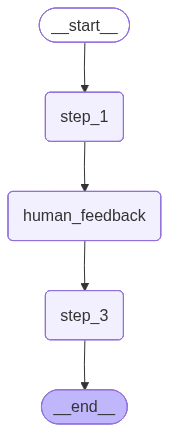

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='973034c7ae2eb5586787f01a6b84d56a'),)}




In [ ]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




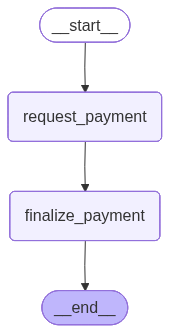

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt
from typing_extensions import TypedDict

# 1. Define Graph State
class State(TypedDict):
    payment_amount: int
    status: str

# 2. Define the Nodes
def request_payment(state: State):
    print(f"💰 Processing request for ₹{state['payment_amount']}...")
    
    # 🛑 THE INTERRUPT: Execution halts here. 
    # It sends a question to the user and waits for their response.
    user_response = interrupt(f"Do you approve paying ₹{state['payment_amount']}?")
    
    # Execution resumes here only AFTER the human responds
    return {"status": user_response}

def finalize_payment(state: State):
    if state["status"].lower() == "yes":
        print("✅ Money sent successfully!")
    else:
        print("❌ Payment cancelled by user.")
    return state

# 3. Build and compile the graph (Memory is REQUIRED for interrupts)
builder = StateGraph(State)
builder.add_node("request_payment", request_payment)
builder.add_node("finalize_payment", finalize_payment)

builder.add_edge(START, "request_payment")
builder.add_edge("request_payment", "finalize_payment")
builder.add_edge("finalize_payment", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))


In [ ]:
config = {"configurable": {"thread_id": "tx_999"}}
initial_state = {"payment_amount": 5000, "status": "pending"}

# Run until it hits the interrupt
events = graph.stream(initial_state, config, stream_mode="values")
for event in events:
    print(event)


{'payment_amount': 5000, 'status': 'pending'}
💰 Processing request for ₹5000...
{'payment_amount': 5000, 'status': 'pending', '__interrupt__': (Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),)}


In [ ]:
state_info = graph.get_state(config)
state_info


StateSnapshot(values={'payment_amount': 5000, 'status': 'pending'}, next=('request_payment',), config={'configurable': {'thread_id': 'tx_999', 'checkpoint_ns': '', 'checkpoint_id': '1f15e9ce-b183-66ec-8000-1cde4924bab9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-02T16:05:47.733783+00:00', parent_config={'configurable': {'thread_id': 'tx_999', 'checkpoint_ns': '', 'checkpoint_id': '1f15e9ce-b13f-68e2-bfff-7363be3035d4'}}, tasks=(PregelTask(id='b29fc660-9b6b-6aa7-255d-74193ff1f8ea', name='request_payment', path=('__pregel_pull', 'request_payment'), error=None, interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),), state=None, result=None),), interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),))

In [ ]:
state_info.tasks[0]

PregelTask(id='b29fc660-9b6b-6aa7-255d-74193ff1f8ea', name='request_payment', path=('__pregel_pull', 'request_payment'), error=None, interrupts=(Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f'),), state=None, result=None)

In [ ]:
state_info.tasks[0].interrupts[0]

Interrupt(value='Do you approve paying ₹5000?', id='bef7349ca160d87cd472ec184378f36f')

In [ ]:
# Assuming your snapshot variable is named 'snapshot'
print("📊 Graph State Values:")
for key, value in state_info.values.items():
    print(f"  {key}: {value}")


📊 Graph State Values:
  payment_amount: 5000
  status: pending


In [ ]:

for interrupt in state_info.interrupts:
    print(f"  ID: {interrupt.id}")
    print(f"  Message: {interrupt.value}")


  ID: bef7349ca160d87cd472ec184378f36f
  Message: Do you approve paying ₹5000?


In [ ]:
from langgraph.types import Command

# Provide the human response to resume the thread
events = graph.stream(Command(resume="yes"), config, stream_mode="values")
for event in events:
    print(event)


{'payment_amount': 5000, 'status': 'pending'}
💰 Processing request for ₹5000...
{'payment_amount': 5000, 'status': 'yes'}
✅ Money sent successfully!
{'payment_amount': 5000, 'status': 'yes'}


In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from typing_extensions import TypedDict

# 1. Define Graph State
class State(TypedDict):
    payment_amount: int
    status: str

# 2. Define the Nodes
def request_payment(state: State):
    print(f"\n[Node] Processing request for ₹{state['payment_amount']}...")
    
    # 🛑 The graph freezes here and waits for a resume command
    user_response = interrupt(f"Do you approve paying ₹{state['payment_amount']}? (yes/no): ")
    
    return {"status": user_response}

def finalize_payment(state: State):
    print("\n[Node] Finalizing transaction...")
    if state["status"].strip().lower() == "yes":
        print("✅ SUCCESS: Money sent successfully!")
    else:
        print("❌ CANCELLED: Payment declined by user.")
    return state

# 3. Build and Compile the Graph with Memory
builder = StateGraph(State)
builder.add_node("request_payment", request_payment)
builder.add_node("finalize_payment", finalize_payment)

builder.add_edge(START, "request_payment")
builder.add_edge("request_payment", "finalize_payment")
builder.add_edge("finalize_payment", END)

memory = InMemorySaver()
graph = builder.compile(checkpointer=memory)

# ==========================================
# 🔄 THE INTERACTIVE CHAT LOOP
# ==========================================

config = {"configurable": {"thread_id": "payment_session_1"}}
initial_input = {"payment_amount": 5000, "status": "pending"}

# This variable will hold our initial inputs or the human resume command
current_input = initial_input 

print("🚀 Starting LangGraph Payment Flow...")

while True:
    # 1. Run the graph with the current input (or resume command)
    for event in graph.stream(current_input, config, stream_mode="updates"):
        pass # Stream executes the nodes behind the scenes
    
    # 2. Check if the graph paused because of an interrupt
    state_info = graph.get_state(config)
    
    if state_info.tasks:
        # Fetch the interrupt message text we defined inside the node
        interrupt_msg = state_info.tasks[0].interrupts[0].value
        
        # Ask the user directly in the terminal
        human_choice = input(f"\n📢 HUMAN INTERVENTION REQUIRED: {interrupt_msg}")
        
        # Prepare the special Command object to pass the answer back into the graph
        current_input = Command(resume=human_choice)
    else:
        # No tasks left means the graph completed its run successfully!
        print("\n🏁 Graph finished execution.")
        break


🚀 Starting LangGraph Payment Flow...

[Node] Processing request for ₹5000...

[Node] Processing request for ₹5000...

[Node] Finalizing transaction...
✅ SUCCESS: Money sent successfully!

🏁 Graph finished execution.
